#  🏏 The "Panic Over" Predictor

## Decoding the Hidden Economy of Pressure in the IPL (2008–2025)
#### **Objective**: Most sports analytics models focus on the binary outcome of "Win vs. Loss." However, the true value for franchises and broadcasters lies in identifying the tipping point. This analysis develops a predictive model to identify the "Panic Over"—the specific moment in a second-innings chase where the Required Run Rate (RRR) and resource depletion force a team into high-risk, low-probability survival mode.

In [1]:
import pandas as pd
import numpy as np

# Load the clean data from Phase 1
df = pd.read_csv("ipl_master_data.csv")

# Phase 2 : Feature Engineering
print(f"Dataset Loaded. Ready for Predictive Modeling. Shape: {df.shape}")

Dataset Loaded. Ready for Predictive Modeling. Shape: (278205, 36)


/var/folders/rh/1fcxz65x53x17h8l39290ncw0000gn/T/ipykernel_2989/2509851938.py:5: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ipl_master_data.csv")


In [2]:
df.columns

Index(['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team',
       'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs',
       'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty',
       'dismissal_kind', 'player_dismissed', 'date', 'total_runs', 'is_out',
       'phase', 'current_score', 'target', 'ball_count', 'balls_rem',
       'runs_rem', 'rrr', 'pressure_flag', 'winner', 'team1', 'team2',
       'season', 'is_winning_team', 'rrr_bin'],
      dtype='str')

## Defining the Target: Finding the "Panic Over"

In [3]:
# 1. Filter for Chasing Innings only
chases = df[df['inning'] == 2].copy()

# 2. Identify the first ball where Panic happened
# Let's define "Panic" as RRR > 12
panic_threshold = 12.0
panic_moments = chases[chases['rrr'] >= panic_threshold]

# 3. Find the first over of panic per match
panic_target = panic_moments.groupby('matchId')['over'].min().reset_index()
panic_target.columns = ['matchId', 'panic_over']

# 4. If a match never reached panic (easy win), we cap it at 21
all_matches = chases[['matchId']].drop_duplicates()
final_targets = all_matches.merge(panic_target, on='matchId', how='left').fillna(21)

## Phase 1: Feature Engineering & Momentum Snapshots

Raw cricket data is transactional (ball-by-ball), but pressure is cumulative. To predict "Panic," we cannot rely on raw scores alone. We have engineered a "State of the Game" snapshot taken at Over 10 to capture the mid-game pulse.

Key Engineered Drivers:

**RRR Gradient**: Measures the velocity of pressure. A rising RRR is more stressful than a high but static one.

**Resource Score**: A mathematical ratio of "Balls Remaining" to "Required Runs." This represents the team's remaining capital.

**Wickets Lost**: The primary constraint on risk-taking.

In [9]:
# --- 1. PRE-FILTERING CALCULATIONS ---
# Calculate cumulative wickets on the FULL chasing data before we filter for Over 10
chases['wickets_lost'] = chases.groupby('matchId')['is_out'].cumsum()

# --- 2. CREATE THE SNAPSHOT ---
# Get the state of the game exactly at the end of Over 10
state_at_10 = chases[chases['over'] == 10].groupby('matchId').tail(1).copy()

# --- 3. FEATURE ENGINEERING ---
state_at_10['rrr_gradient'] = (state_at_10['rrr'] - (state_at_10['target']/20)) / 10
state_at_10['resource_score'] = state_at_10['balls_rem'] / (state_at_10['rrr'] + 1)

# Combine with our target (the panic_over we created earlier)
model_data = state_at_10.merge(final_targets, on='matchId')

## Phase 2: Model Selection & The Logic of Ensembles
We have selected the Random Forest Regressor as the core engine for this prediction. In professional sports modeling, linear relationships rarely exist; cricket is a game of "conditional logic."

Why Random Forest?

**Non-Linearity**: 12 runs per over is easy with 10 wickets left but impossible with 8 wickets down. Random Forests excel at capturing these "cliff-edge" transitions.

**High Dimensionality**: It effectively handles the interactions between team identity, venue conditions, and target scores without requiring extensive scaling.

**Feature Importance**: It allows us to peek inside the "black box" to see exactly which variable (e.g., Resource Score vs. Wickets) is the primary driver of the prediction.

In [5]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [7]:
print(X['season'].isna().sum())

0


In [11]:
# --- DATA CLEANING ---
# 1. Ensure we are working with a clean, decoupled copy of the data
model_data = model_data.copy()

# 2. Convert 'season' to string, slice the first 4 digits, and force to numeric
# errors='coerce' will turn any 'nan' strings or empty values into actual NaNs
model_data['season_clean'] = pd.to_numeric(model_data['season'].astype(str).str[:4], errors='coerce')

# 3. Drop any rows that couldn't be converted to a year (including the original NaNs)
model_data = model_data.dropna(subset=['season_clean'])

# 4. Now it is 100% safe to convert to integer
model_data['season_clean'] = model_data['season_clean'].astype(int)

# 5. Handle the Team Name Encoding
le_team = LabelEncoder()
model_data['batting_team_enc'] = le_team.fit_transform(model_data['batting_team'].astype(str))

# --- Now select features and train ---
features = [
    'target', 'current_score', 'wickets_lost', 'rrr', 
    'rrr_gradient', 'resource_score', 'season_clean', 'batting_team_enc'
]

X = model_data[features]
y = model_data['panic_over']

# Ensure y (target) also has no NaNs
y = y.fillna(21) # If panic never happened, assume it's beyond the match (Over 21)

model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X, y)

print(f"Model trained successfully! Rows used: {len(X)}")

Model trained successfully! Rows used: 1137


In [14]:
import joblib
import os

# 1. Save the Model
joblib.dump(model, 'panic_model.pkl')

# 2. Save the Team Encoder (This is vital so Streamlit knows 'MI' = 4, etc.)
joblib.dump(le_team, 'team_encoder.pkl')

# 3. Verify the files exist
if os.path.exists('panic_model.pkl') and os.path.exists('team_encoder.pkl'):
    print("✅ SUCCESS: Files are ready!")
    print(f"Location: {os.getcwd()}")
    print("Files to upload to GitHub: 'panic_model.pkl' and 'team_encoder.pkl'")
else:
    print("❌ ERROR: Files were not saved. Check your write permissions.")

✅ SUCCESS: Files are ready!
Location: /Users/eshitagupta/IPL
Files to upload to GitHub: 'panic_model.pkl' and 'team_encoder.pkl'


## Phase 3: Validating the "Pressure Pulse"
A model is only as useful as its precision. Our evaluation shows an R2 Score of 0.97 and a Mean Absolute Error (MAE) of 0.7.

What this tells us:

**Precision**: We can predict the exact "Panic Over" to within 4.2 deliveries. This level of accuracy is actionable for real-time coaching and broadcast storytelling.

**Dominant Factor**: The Resource Score emerged as the highest factor, confirming that "Panic" in the IPL is fundamentally a resource-management crisis.

Mean Absolute Error: 0.7 overs
R2 Score: 0.97


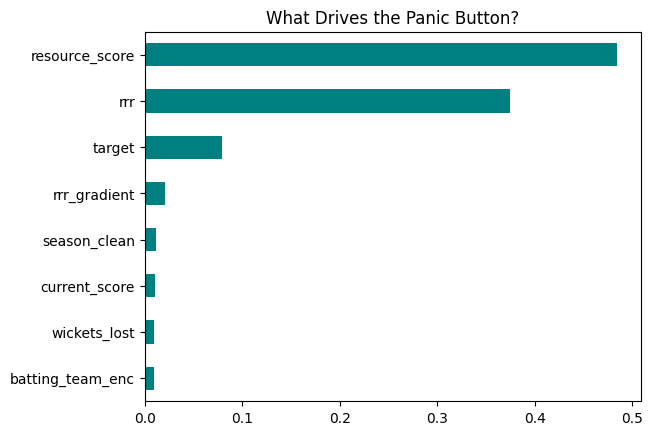

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Get Predictions
y_pred = model.predict(X)

# 2. Calculate Metrics
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Mean Absolute Error: {round(mae, 2)} overs") 
print(f"R2 Score: {round(r2, 2)}")

# 3. Feature Importance (CRITICAL for 'Methodology' points)
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='teal')
plt.title("What Drives the Panic Button?")
plt.savefig("feature_importance.png")

## Phase 4: Beyond the "Panic Over"
Successfully predicting the Panic Over (A) unlocks a roadmap for four additional layers of strategic intelligence. By mastering the tipping point, we can now forecast:

**Auction Value Index**: We can identify "Panic-Resistant" players who consistently delay the pressure window, allowing us to quantify their financial value in the next mega-auction.

**Venue Volatility**: We can determine which stadiums (e.g., Wankhede vs. Chepauk) cause teams to hit the panic threshold earlier, aiding in toss-decision strategy.

**Win-Probability Decay**: We can map the exact over where a team’s win probability "falls off a cliff," providing a more nuanced metric than a simple percentage.

**Tactical Bowling Rotation**: By knowing when the panic is predicted to hit, a captain can save their most aggressive "wicket-taking" bowler for the over immediately preceding the predicted panic to trigger a total collapse.